# Figure 11: TransmonCross varied parameters

Single-device view labeling the three varied Qiskit/Quantum Metal output parameters from the manuscript.


wrote figures/paper/manuscript_exports/figure11_transmon_qiskit_parameters.png
wrote figures/paper/manuscript_exports/figure11_transmon_qiskit_parameters.pdf


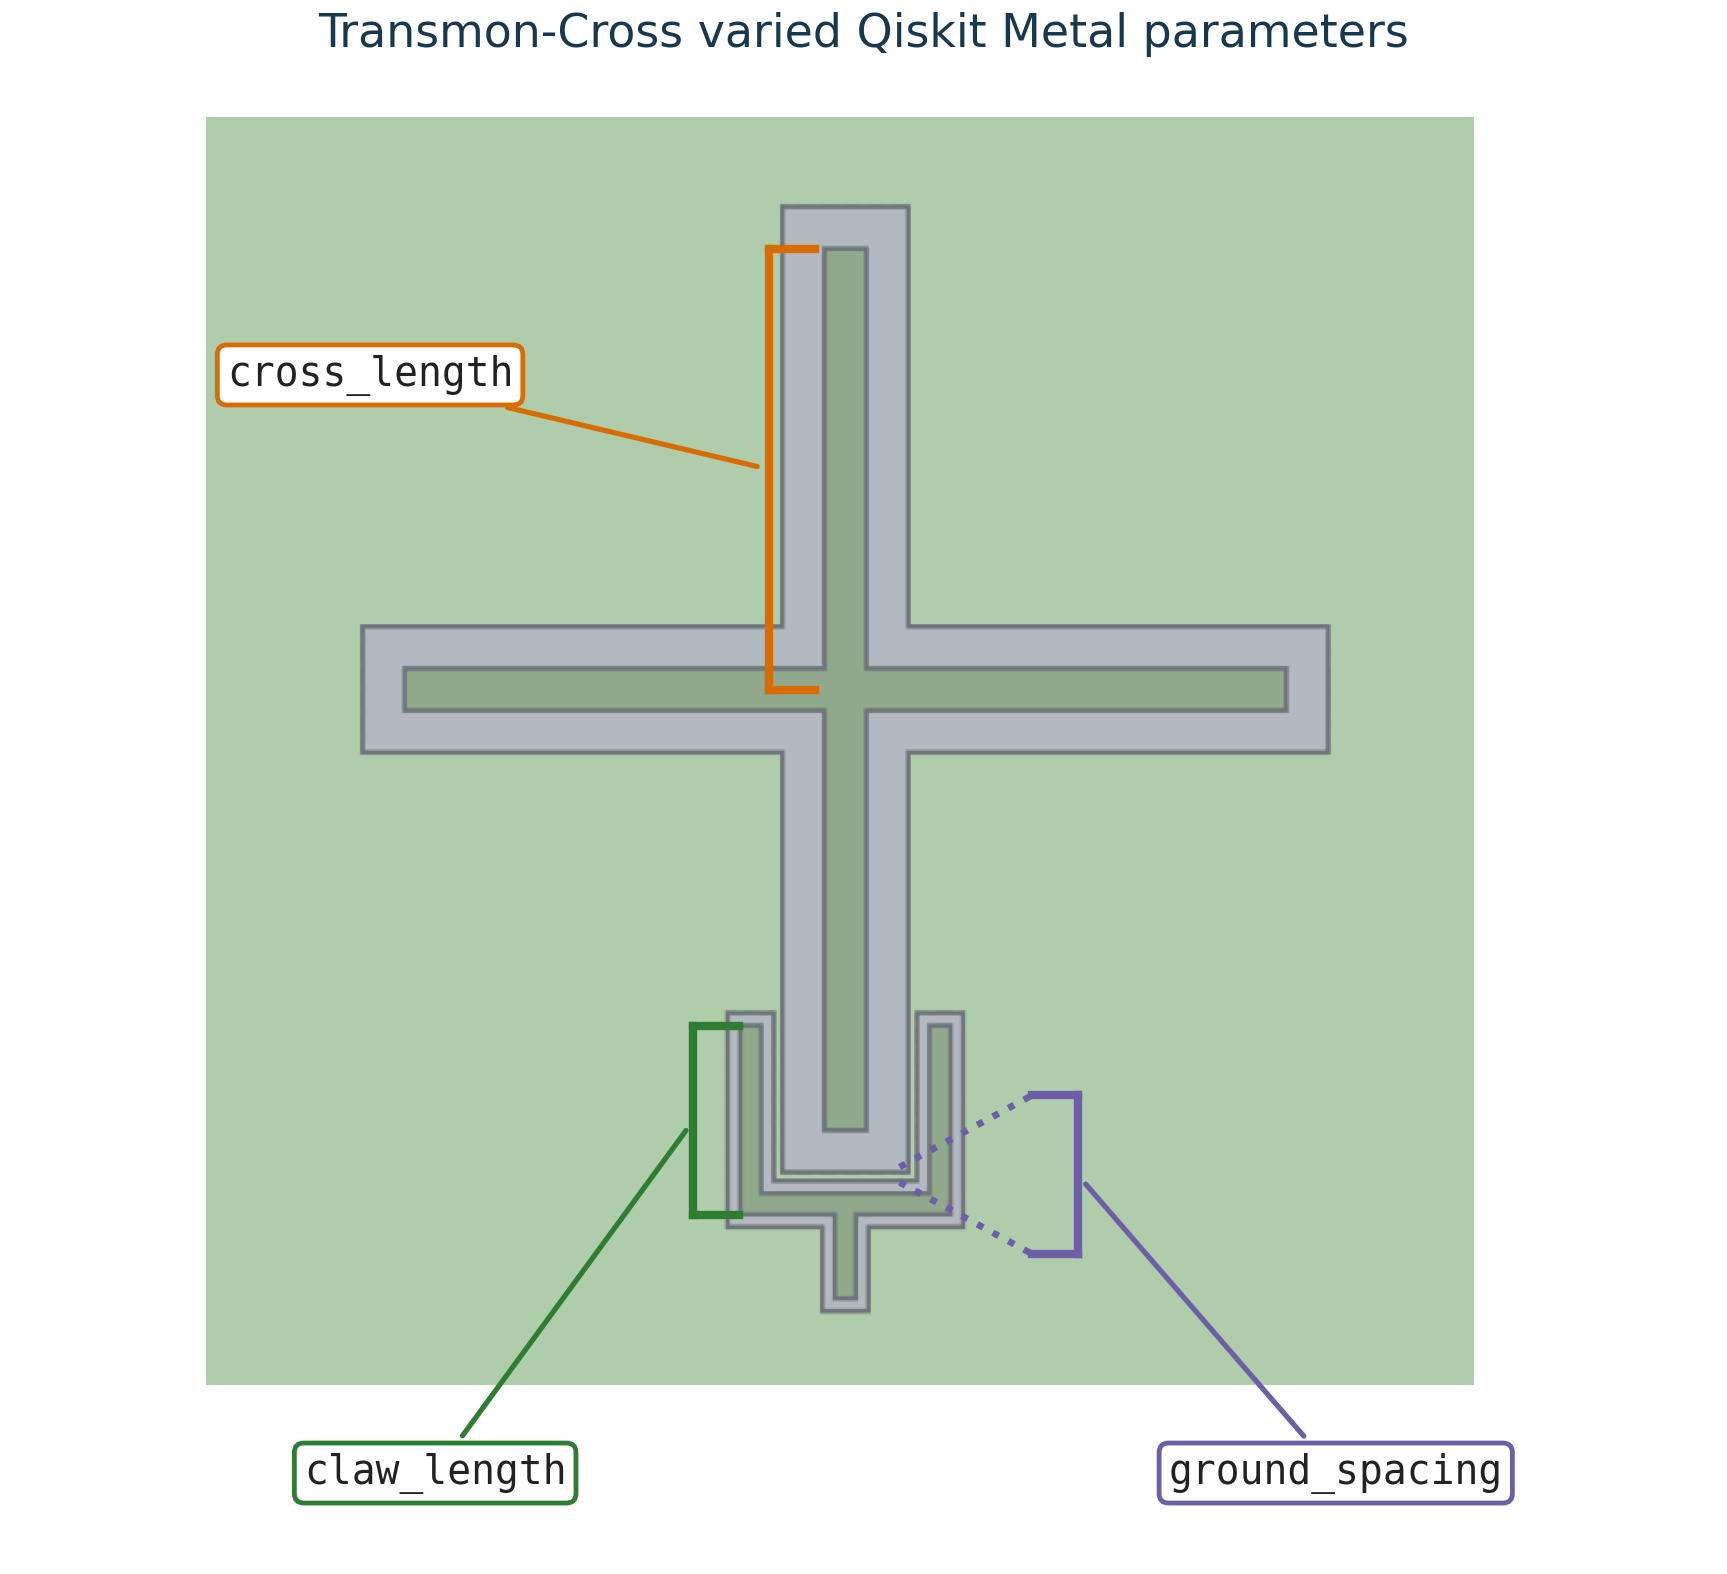

In [1]:
import io
from pathlib import Path

import fitz  # PyMuPDF
import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
from PIL import Image

# Source files are resolved from either the repository root or figures/paper.
source_dir_candidates = [
    Path("source_materials"),
    Path("figures/paper/source_materials"),
]
for candidate in source_dir_candidates:
    if (candidate / "ref_design_76.pdf").exists():
        SOURCE_DIR = candidate
        break
else:
    raise FileNotFoundError("Could not find source_materials/ref_design_76.pdf")

if SOURCE_DIR.name == "source_materials":
    EXPORT_DIR = SOURCE_DIR.parent / "manuscript_exports"
else:
    EXPORT_DIR = Path("figures/paper/manuscript_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Crop and rotate the rendered Qiskit/Quantum Metal PDF view.
crop_rect = fitz.Rect(190, 50, 470, 330)
dpi = 180
rotation_angle = 90

with fitz.open(SOURCE_DIR / "ref_design_76.pdf") as doc:
    pix = doc[0].get_pixmap(clip=crop_rect, dpi=dpi)
transmon = Image.open(io.BytesIO(pix.tobytes("png"))).rotate(rotation_angle, expand=True)

# Original label coordinates were tuned on a 584 px square crop. Scale them
# so changing the render DPI keeps the annotations aligned to the geometry.
base_width_px = 584
scale = transmon.size[0] / base_width_px
s = lambda value: value * scale

colors = {
    "cross_length": "#D96C00",
    "claw_length": "#2E7D32",
    "ground_spacing": "#6D5EA8",
}

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.imshow(transmon, zorder=1)
ax.set_xlim(s(-90), s(695))
ax.set_ylim(s(665), s(-20))
ax.axis("off")
ax.set_title("Transmon-Cross varied Qiskit Metal parameters", color="#17384F", fontsize=11, pad=7)


def draw_vertical_bracket(x, y1, y2, color):
    tick = s(21)
    sx = s(x)
    sy1 = s(y1)
    sy2 = s(y2)
    ax.plot([sx - tick, sx], [sy1, sy1], color=color, lw=2, zorder=4)
    ax.plot([sx - tick, sx], [sy2, sy2], color=color, lw=2, zorder=4)
    ax.plot([sx - tick, sx - tick], [sy1, sy2], color=color, lw=2, zorder=4)
    return sx - tick, (sy1 + sy2) / 2


def draw_callout(text, xy, xytext, color):
    ax.annotate(
        text,
        xy=xy,
        xytext=(s(xytext[0]), s(xytext[1])),
        textcoords="data",
        ha="center",
        va="center",
        fontsize=9.5,
        family="monospace",
        color="#222222",
        bbox={
            "boxstyle": "round,pad=0.24",
            "facecolor": "white",
            "edgecolor": color,
            "linewidth": 1.15,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "lw": 1.25,
            "shrinkA": 2,
            "shrinkB": 3,
        },
        zorder=10,
    )


# design_options.cross_length
cross_xy = draw_vertical_bracket(280, 60, 263, colors["cross_length"])
draw_callout("cross_length", cross_xy, (75, 118), colors["cross_length"])

# design_options.connection_pads.readout.claw_length
claw_xy = draw_vertical_bracket(245, 418, 505, colors["claw_length"])
draw_callout(
    "claw_length",
    claw_xy,
    (105, 624),
    colors["claw_length"],
)

# design_options.connection_pads.readout.ground_spacing
x1, x2 = 319, 380
top_y1, top_y2 = 483, 450
bottom_y1 = 490
bottom_y2 = bottom_y1 + (top_y1 - top_y2)
tick = s(21)
gap_color = colors["ground_spacing"]
ax.plot([s(x1), s(x2)], [s(top_y1), s(top_y2)], linestyle="dotted", color=gap_color, lw=1.6, zorder=5)
ax.plot([s(x1), s(x2)], [s(bottom_y1), s(bottom_y2)], linestyle="dotted", color=gap_color, lw=1.6, zorder=5)
ax.plot([s(x2) + tick, s(x2)], [s(top_y2), s(top_y2)], color=gap_color, lw=2, zorder=5)
ax.plot([s(x2) + tick, s(x2)], [s(bottom_y2), s(bottom_y2)], color=gap_color, lw=2, zorder=5)
ax.plot([s(x2) + tick, s(x2) + tick], [s(top_y2), s(bottom_y2)], color=gap_color, lw=2, zorder=5)
draw_callout(
    "ground_spacing",
    (s(x2) + tick, (s(top_y2) + s(bottom_y2)) / 2),
    (520, 624),
    gap_color,
)

fig.tight_layout(pad=0.1)

png_path = EXPORT_DIR / "figure11_transmon_qiskit_parameters.png"
pdf_path = EXPORT_DIR / "figure11_transmon_qiskit_parameters.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.04)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.04)
print(f"wrote {png_path}")
print(f"wrote {pdf_path}")
fig
